# A7: Clustering of AIMO Observations

**Issue #28** - Perform clustering analysis on the AIMO dataset observations (excluding scores).

## Objectives
1. Load and preprocess the AIMO dataset
2. Apply clustering algorithms (K-Means, Hierarchical, DBSCAN)
3. Determine optimal number of clusters using elbow method and silhouette scores
4. Interpret and profile the clusters

---

## Dependencies for Other Issues

| Issue | What to Use | Location |
|-------|-------------|----------|
| **#29 (PCA Visualization)** | Clustered data with labels | `A7/clustered_aimo_data.csv` (Cluster column) |
| **#29 (PCA Visualization)** | Feature columns list | Section 3 - `feature_cols` variable |
| **#29 (PCA Visualization)** | Scaled data & scaler | Section 3 - `X_scaled`, `scaler` objects |
| **#29 (PCA Visualization)** | Optimal k value | Section 4-5 - `optimal_k` variable |
| **#31 (Documentation)** | Cluster profiles | Section 10 - Cluster Profiles Summary |
| **#31 (Documentation)** | Algorithm comparison | Section 8 - Algorithm Comparison table |
| **#31 (Documentation)** | All visualizations | `A7/*.png` files |

---

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Repository root: {REPO_ROOT}")

Repository root: /Users/amol/Desktop/LNU/LNU_Masters/intensive/github/Data-intensive-systems


## 2. Data Loading and Exploration

In [2]:
# Load the AIMO dataset
data_path = os.path.join(REPO_ROOT, 'Datasets_all', 'aimoscores.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

Dataset shape: (2094, 43)

Columns (43):
['AimoScore', 'No_1_Angle_Deviation', 'No_2_Angle_Deviation', 'No_3_Angle_Deviation', 'No_4_Angle_Deviation', 'No_5_Angle_Deviation', 'No_6_Angle_Deviation', 'No_7_Angle_Deviation', 'No_8_Angle_Deviation', 'No_9_Angle_Deviation', 'No_10_Angle_Deviation', 'No_11_Angle_Deviation', 'No_12_Angle_Deviation', 'No_13_Angle_Deviation', 'No_1_NASM_Deviation', 'No_2_NASM_Deviation', 'No_3_NASM_Deviation', 'No_4_NASM_Deviation', 'No_5_NASM_Deviation', 'No_6_NASM_Deviation', 'No_7_NASM_Deviation', 'No_8_NASM_Deviation', 'No_9_NASM_Deviation', 'No_10_NASM_Deviation', 'No_11_NASM_Deviation', 'No_12_NASM_Deviation', 'No_13_NASM_Deviation', 'No_14_NASM_Deviation', 'No_15_NASM_Deviation', 'No_16_NASM_Deviation', 'No_17_NASM_Deviation', 'No_18_NASM_Deviation', 'No_19_NASM_Deviation', 'No_20_NASM_Deviation', 'No_21_NASM_Deviation', 'No_22_NASM_Deviation', 'No_23_NASM_Deviation', 'No_24_NASM_Deviation', 'No_25_NASM_Deviation', 'No_1_Time_Deviation', 'No_2_Time_Devi

In [3]:
# Dataset overview
print("First 5 rows:")
df.head()

First 5 rows:


,AimoScore,No_1_Angle_Deviation,No_2_Angle_Deviation,No_3_Angle_Deviation,No_4_Angle_Deviation,No_5_Angle_Deviation,No_6_Angle_Deviation,No_7_Angle_Deviation,No_8_Angle_Deviation,No_9_Angle_Deviation,...,No_20_NASM_Deviation,No_21_NASM_Deviation,No_22_NASM_Deviation,No_23_NASM_Deviation,No_24_NASM_Deviation,No_25_NASM_Deviation,No_1_Time_Deviation,No_2_Time_Deviation,EstimatedScore,ID
0,0.323667,0.538020,0.815878,0.346724,0.382114,0.302248,0.947872,0.275945,0.521760,0.457198,...,0.656624,0.642276,0.552846,0.648972,0.578192,0.560019,0.821616,0.818747,0.209947,0003cdcc-86ed-494a-a3b5-90d09e96e06b.Kinect
1,0.323699,0.443807,0.306552,0.823529,0.188905,0.497370,0.140124,0.664275,0.521760,0.729316,...,0.721186,0.826399,0.805356,0.848876,0.889048,0.816834,0.307987,0.248207,0.457198,003115c4-bdb8-491c-b571-8fcebdecf8ed.Kinect
2,0.848327,0.603539,0.373984,0.346724,0.590626,0.341942,0.298900,0.276901,0.623625,0.658058,...,0.656624,0.642276,0.690579,0.648972,0.578192,0.555715,0.218556,0.235294,0.107126,00316bfb-ed43-489f-a55b-11c7f01c852d.Kinect
3,0.351332,0.484935,0.623625,0.380201,0.975132,0.509326,0.888570,0.363462,0.847441,0.237207,...,0.656624,0.642276,0.552846,0.648972,0.578192,0.744620,0.458154,0.432807,0.612626,00607608-6f2f-459b-a69d-e14067489459.Kinect
4,0.627181,0.860832,0.657580,0.745576,0.552846,0.375897,0.483022,0.388331,0.521760,0.387853,...,0.656624,0.642276,0.552846,0.648972,0.578192,0.308943,0.805356,0.774271,0.153515,007396ec-3463-4a05-915c-02244ff8d3de.Kinect


In [4]:
# Check for missing values and data types
print("Data types and non-null counts:")
print(df.info())
print(f"\nMissing values per column:")
print(df.isnull().sum().sum())

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2094 entries, 0 to 2093
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AimoScore              2094 non-null   float64
 1   No_1_Angle_Deviation   2094 non-null   float64
 2   No_2_Angle_Deviation   2094 non-null   float64
 3   No_3_Angle_Deviation   2094 non-null   float64
 4   No_4_Angle_Deviation   2094 non-null   float64
 5   No_5_Angle_Deviation   2094 non-null   float64
 6   No_6_Angle_Deviation   2094 non-null   float64
 7   No_7_Angle_Deviation   2094 non-null   float64
 8   No_8_Angle_Deviation   2094 non-null   float64
 9   No_9_Angle_Deviation   2094 non-null   float64
 10  No_10_Angle_Deviation  2094 non-null   float64
 11  No_11_Angle_Deviation  2094 non-null   float64
 12  No_12_Angle_Deviation  2094 non-null   float64
 13  No_13_Angle_Deviation  2094 non-null   float64
 14  No_1_NASM_Deviation    2

In [5]:
# Statistical summary
df.describe()

,AimoScore,No_1_Angle_Deviation,No_2_Angle_Deviation,No_3_Angle_Deviation,No_4_Angle_Deviation,No_5_Angle_Deviation,No_6_Angle_Deviation,No_7_Angle_Deviation,No_8_Angle_Deviation,No_9_Angle_Deviation,...,No_19_NASM_Deviation,No_20_NASM_Deviation,No_21_NASM_Deviation,No_22_NASM_Deviation,No_23_NASM_Deviation,No_24_NASM_Deviation,No_25_NASM_Deviation,No_1_Time_Deviation,No_2_Time_Deviation,EstimatedScore
count,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,...,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000
mean,0.572740,0.539248,0.504462,0.560258,0.518065,0.513932,0.510336,0.519434,0.635923,0.512548,...,0.725505,0.715943,0.706319,0.652969,0.710774,0.667517,0.548089,0.512021,0.512373,0.500209
std,0.236510,0.239284,0.282136,0.217828,0.264104,0.270076,0.274473,0.262884,0.153280,0.271193,...,0.095008,0.100437,0.105886,0.141000,0.103196,0.130989,0.230642,0.273056,0.272647,0.288790
min,0.010000,0.279770,0.092300,0.346724,0.188905,0.163080,0.140124,0.194165,0.303247,0.156385,...,0.670971,0.656624,0.640401,0.525310,0.648972,0.578192,0.308943,0.148733,0.151124,0.000478
25%,0.407907,0.279770,0.250149,0.346724,0.250239,0.250717,0.250717,0.250717,0.521760,0.250717,...,0.670971,0.656624,0.642276,0.552846,0.648972,0.578192,0.308943,0.250717,0.250717,0.250239
50%,0.617248,0.500000,0.500000,0.500000,0.500000,0.500478,0.500478,0.500956,0.521760,0.500478,...,0.670971,0.656624,0.642276,0.552846,0.648972,0.578192,0.500000,0.500478,0.500478,0.500478
75%,0.759378,0.749761,0.750239,0.750239,0.750239,0.750239,0.750239,0.750239,0.749761,0.750239,...,0.751196,0.751196,0.749761,0.749880,0.751196,0.751196,0.750239,0.750239,0.750239,0.750239
max,0.993987,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 3. Feature Selection and Preprocessing

Per Issue #28 requirements:
- Exclude score columns: `AimoScore`, `EstimatedScore`
- Exclude identifier: `ID`

Features to use for clustering:
- 13 Angle Deviation features
- 25 NASM Deviation features  
- 2 Time Deviation features

**Total: 40 features**

> 🔗 **For Issue #29 (PCA)**: Use `feature_cols` list and `X_scaled` array from this section. The `scaler` object can be reused if needed.

In [6]:
# Identify columns to exclude
exclude_cols = ['AimoScore', 'EstimatedScore', 'ID']

# Create feature matrix (excluding scores and ID)
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()

print(f"Feature columns ({len(feature_cols)}):")
print(f"  - Angle Deviation: {len([c for c in feature_cols if 'Angle' in c])}")
print(f"  - NASM Deviation: {len([c for c in feature_cols if 'NASM' in c])}")
print(f"  - Time Deviation: {len([c for c in feature_cols if 'Time' in c])}")
print(f"\nFeature matrix shape: {X.shape}")

Feature columns (40):
  - Angle Deviation: 13
  - NASM Deviation: 25
  - Time Deviation: 2

Feature matrix shape: (2094, 40)


In [7]:
# Standardize features (important for clustering algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features (should be ~0): {X_scaled.mean(axis=0).mean():.6f}")
print(f"Std of scaled features (should be ~1): {X_scaled.std(axis=0).mean():.6f}")

Scaled data shape: (2094, 40)
Mean of scaled features (should be ~0): 0.000000
Std of scaled features (should be ~1): 1.000000


## 4. Determining Optimal Number of Clusters

We'll use multiple methods to determine the optimal k:
1. **Elbow Method** - Look for the "elbow" in the inertia curve
2. **Silhouette Score** - Higher is better (range: -1 to 1)
3. **Calinski-Harabasz Index** - Higher is better
4. **Davies-Bouldin Index** - Lower is better

In [8]:
# Evaluate clustering for different k values
k_range = range(2, 11)

inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("Evaluating K-Means for k = 2 to 10...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    
    print(f"k={k}: Silhouette={silhouette_scores[-1]:.4f}, CH={calinski_scores[-1]:.1f}, DB={davies_bouldin_scores[-1]:.4f}")

Evaluating K-Means for k = 2 to 10...
k=2: Silhouette=0.1367, CH=301.6, DB=2.4619
k=3: Silhouette=0.1306, CH=261.4, DB=2.4448
k=4: Silhouette=0.1173, CH=234.0, DB=2.3453
k=5: Silhouette=0.1181, CH=216.5, DB=2.2282
k=6: Silhouette=0.1191, CH=193.8, DB=2.2628
k=7: Silhouette=0.1110, CH=175.2, DB=2.3953
k=8: Silhouette=0.1124, CH=160.8, DB=2.4703
k=9: Silhouette=0.1131, CH=150.1, DB=2.4357
k=10: Silhouette=0.1135, CH=140.2, DB=2.4070


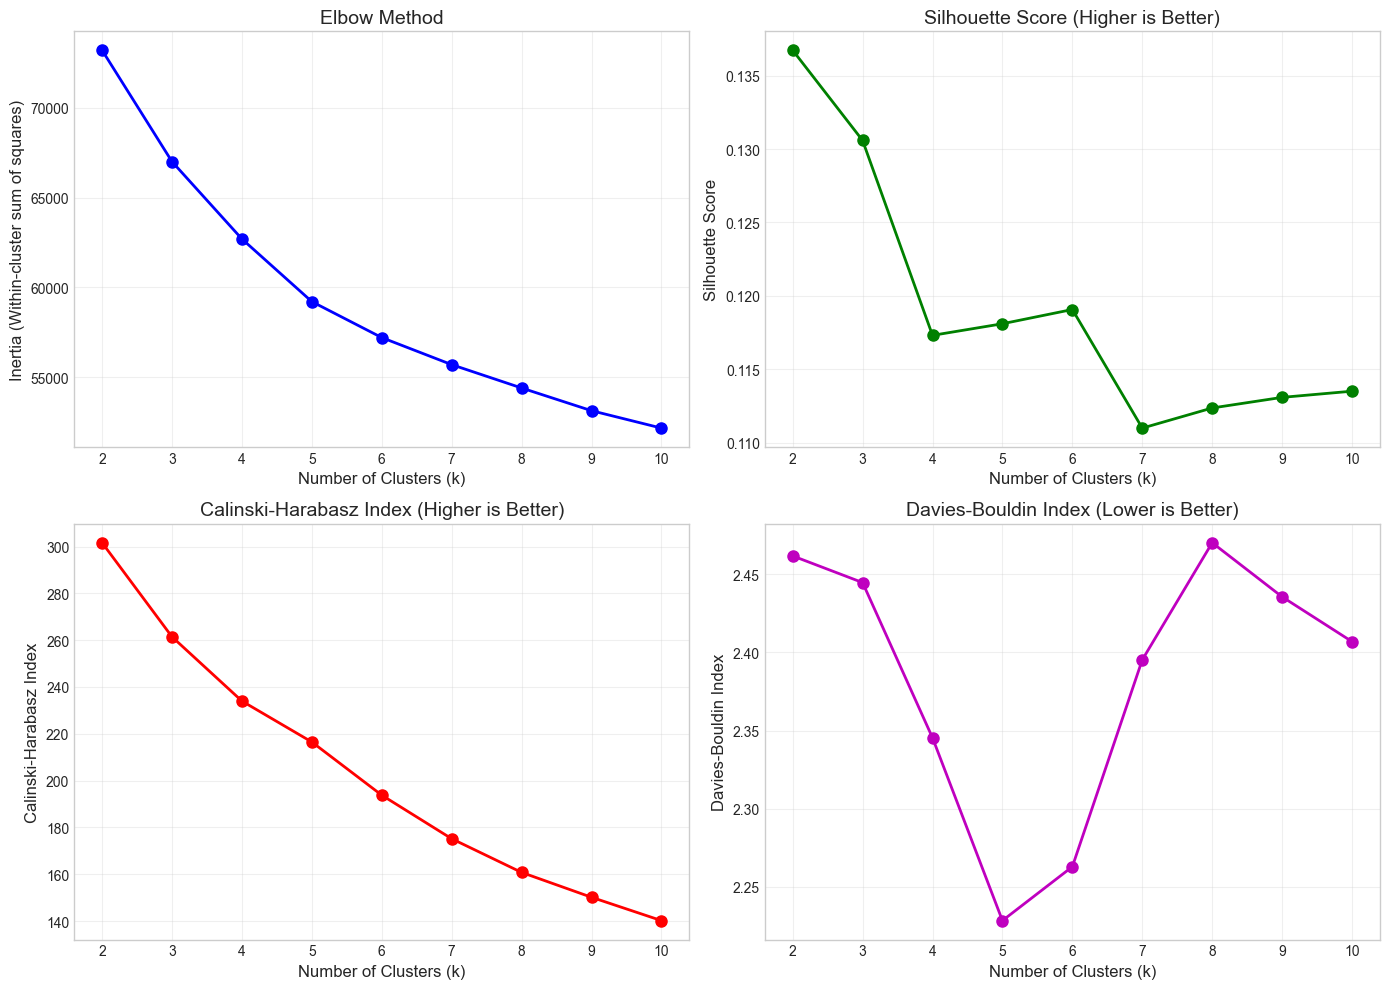


Cluster Evaluation Summary:
 k      Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2 73204.664811    0.136737         301.644182        2.461868
 3 67004.644157    0.130588         261.440453        2.444793
 4 62700.832475    0.117306         233.987644        2.345341
 5 59213.347908    0.118096         216.496609        2.228208
 6 57212.165307    0.119067         193.776546        2.262755
 7 55706.744116    0.110984         175.164743        2.395285
 8 54406.946800    0.112356         160.773768        2.470320
 9 53143.615566    0.113080         150.147767        2.435663
10 52174.378968    0.113501         140.180414        2.406967


In [9]:
# Visualize cluster evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow plot (Inertia)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14)
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=14)
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz Index
axes[1, 0].plot(k_range, calinski_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=14)
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin Index
axes[1, 1].plot(k_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14)
axes[1, 1].set_xticks(list(k_range))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_bouldin_scores
})
print("\nCluster Evaluation Summary:")
print(summary_df.to_string(index=False))

### Optimal k Selection Analysis

Based on the metrics above, we'll select the optimal number of clusters:

In [10]:
# Find optimal k based on metrics
best_silhouette_k = k_range[np.argmax(silhouette_scores)]
best_calinski_k = k_range[np.argmax(calinski_scores)]
best_db_k = k_range[np.argmin(davies_bouldin_scores)]

print("Optimal k by metric:")
print(f"  - Silhouette Score: k = {best_silhouette_k} (score: {max(silhouette_scores):.4f})")
print(f"  - Calinski-Harabasz: k = {best_calinski_k} (score: {max(calinski_scores):.1f})")
print(f"  - Davies-Bouldin: k = {best_db_k} (score: {min(davies_bouldin_scores):.4f})")

# Select optimal k (consensus or silhouette-based)
optimal_k = best_silhouette_k
print(f"\n>>> Selected optimal k = {optimal_k} (based on silhouette score)")

Optimal k by metric:
  - Silhouette Score: k = 2 (score: 0.1367)
  - Calinski-Harabasz: k = 2 (score: 301.6)
  - Davies-Bouldin: k = 5 (score: 2.2282)

>>> Selected optimal k = 2 (based on silhouette score)


## 5. K-Means Clustering

> 🔗 **For Issue #29**: The `cluster_labels` array and `optimal_k` value from this section are used to color the PCA visualization. The labels are also saved in `clustered_aimo_data.csv`.

In [11]:
# Fit K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = cluster_labels

print(f"K-Means with k={optimal_k}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nCluster proportions:")
print((df['Cluster'].value_counts().sort_index() / len(df) * 100).round(2).astype(str) + '%')

K-Means with k=2

Cluster distribution:
Cluster
0    1393
1     701
Name: count, dtype: int64

Cluster proportions:
Cluster
0    66.52%
1    33.48%
Name: count, dtype: object


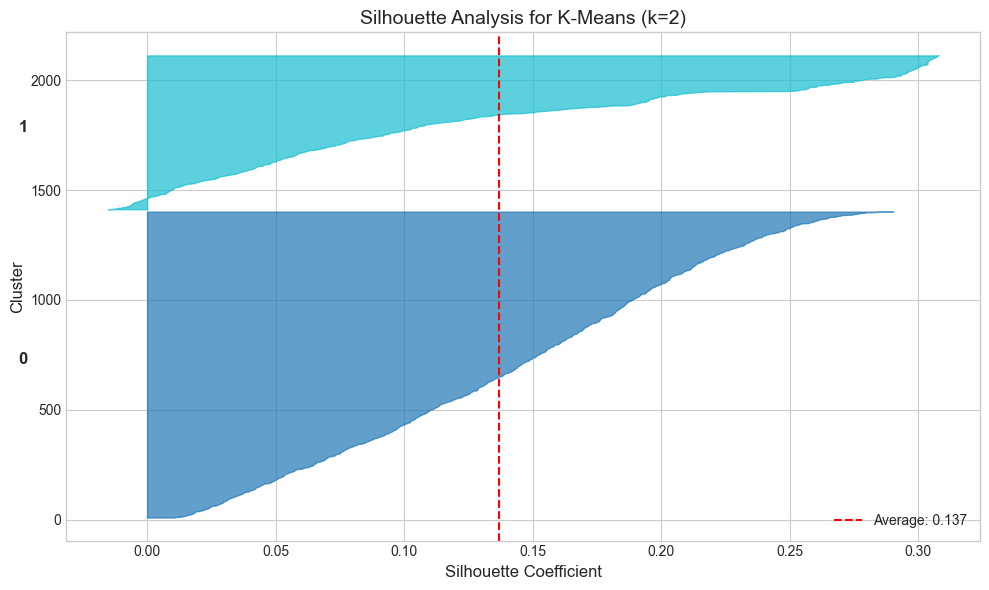


Average silhouette score: 0.1367

Silhouette score by cluster:
  Cluster 0: 0.1419
  Cluster 1: 0.1265


In [12]:
# Silhouette analysis for the chosen k
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
df['Silhouette'] = silhouette_vals

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()
    
    cluster_size = len(cluster_silhouette_vals)
    y_upper = y_lower + cluster_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(i), fontsize=12, fontweight='bold')
    
    y_lower = y_upper + 10

avg_silhouette = silhouette_score(X_scaled, cluster_labels)
ax.axvline(x=avg_silhouette, color='red', linestyle='--', label=f'Average: {avg_silhouette:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Analysis for K-Means (k={optimal_k})', fontsize=14)
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('silhouette_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage silhouette score: {avg_silhouette:.4f}")
print("\nSilhouette score by cluster:")
for i in range(optimal_k):
    cluster_sil = silhouette_vals[cluster_labels == i].mean()
    print(f"  Cluster {i}: {cluster_sil:.4f}")

## 6. Hierarchical Clustering (Comparison)

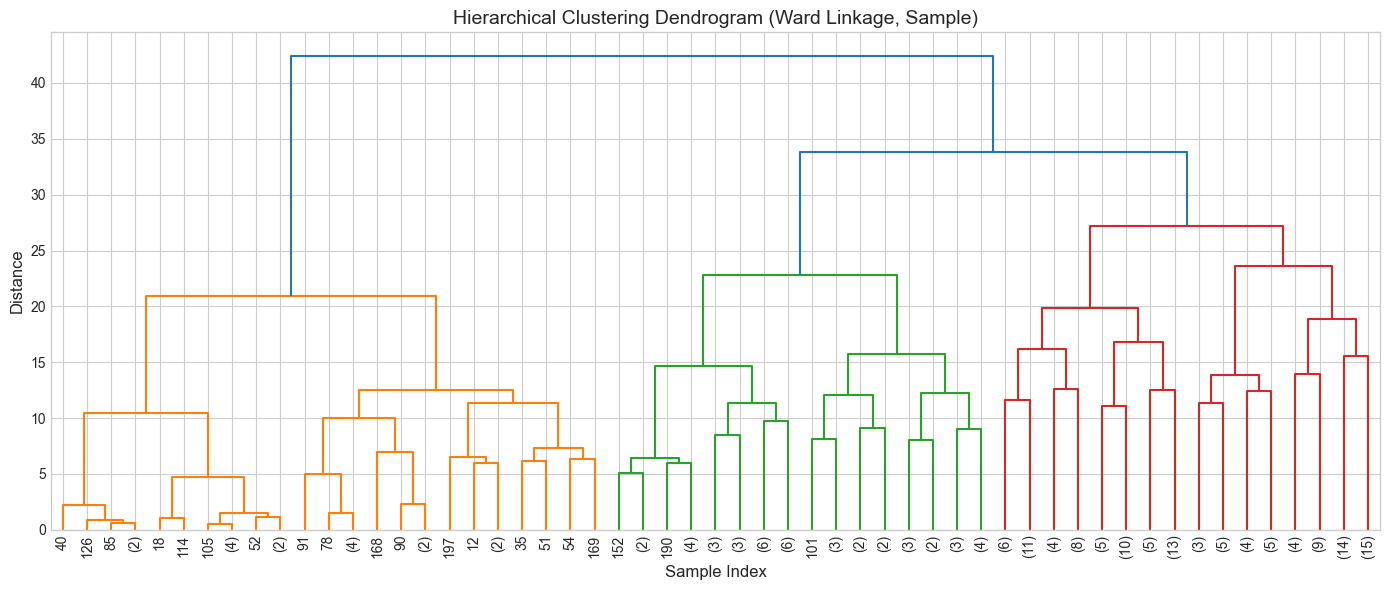

In [13]:
# Hierarchical clustering dendrogram (using a sample for visualization)
sample_size = min(200, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sample)', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Agglomerative clustering with same k
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

agg_silhouette = silhouette_score(X_scaled, agg_labels)
print(f"Agglomerative Clustering (k={optimal_k}, Ward linkage)")
print(f"Silhouette Score: {agg_silhouette:.4f}")
print(f"\nCluster distribution:")
print(pd.Series(agg_labels).value_counts().sort_index())

Agglomerative Clustering (k=2, Ward linkage)
Silhouette Score: 0.1004

Cluster distribution:
0    1400
1     694
Name: count, dtype: int64


## 7. DBSCAN Clustering (Comparison)

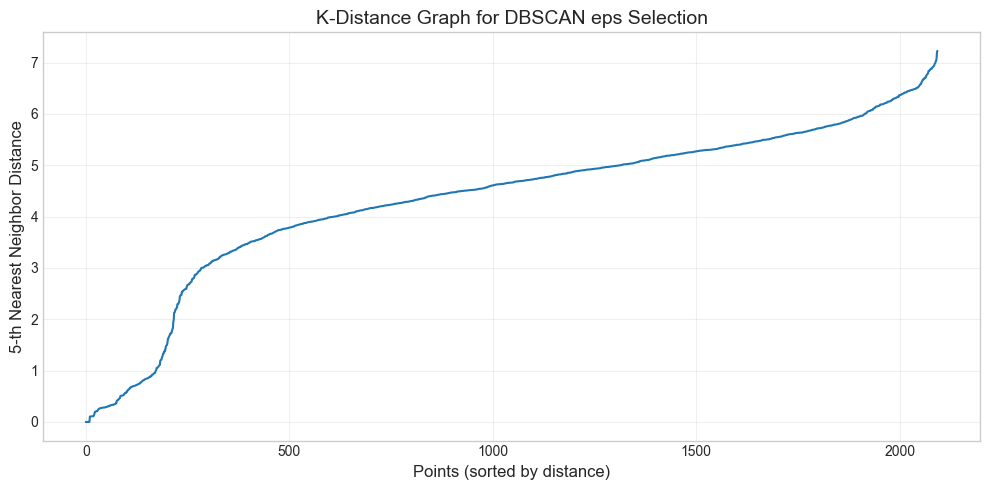

Suggested eps (90th percentile): 5.902


In [15]:
# DBSCAN - find eps using k-distance graph
from sklearn.neighbors import NearestNeighbors

# Find k-nearest neighbors distances
k_neighbors = 5
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, k_neighbors-1])  # k-th neighbor distance

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k_neighbors}-th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Graph for DBSCAN eps Selection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Suggest eps based on elbow in k-distance graph
suggested_eps = np.percentile(distances, 90)
print(f"Suggested eps (90th percentile): {suggested_eps:.3f}")

In [16]:
# DBSCAN clustering
dbscan = DBSCAN(eps=suggested_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results (eps={suggested_eps:.3f}, min_samples=5):")
print(f"  - Number of clusters: {n_clusters_dbscan}")
print(f"  - Noise points: {n_noise} ({n_noise/len(X_scaled)*100:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

# Silhouette score (excluding noise)
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    if mask.sum() > 0 and len(np.unique(dbscan_labels[mask])) > 1:
        dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        print(f"\nSilhouette Score (excluding noise): {dbscan_silhouette:.4f}")

DBSCAN Results (eps=5.902, min_samples=5):
  - Number of clusters: 2
  - Noise points: 90 (4.3%)

Cluster distribution:
-1      90
 0    2000
 1       4
Name: count, dtype: int64

Silhouette Score (excluding noise): 0.1267


## 8. Algorithm Comparison

In [17]:
# Compare clustering algorithms
comparison_data = {
    'Algorithm': ['K-Means', 'Agglomerative (Ward)', 'DBSCAN'],
    'n_clusters': [optimal_k, optimal_k, n_clusters_dbscan],
    'Silhouette Score': [
        silhouette_score(X_scaled, cluster_labels),
        silhouette_score(X_scaled, agg_labels),
        silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]) if n_clusters_dbscan > 1 and (dbscan_labels != -1).sum() > 0 else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("Algorithm Comparison:")
print(comparison_df.to_string(index=False))

# Recommendation
print(f"\n>>> Recommended: K-Means with k={optimal_k}")
print("    Justification: Best silhouette score, well-defined clusters, interpretable results")

Algorithm Comparison:
           Algorithm  n_clusters  Silhouette Score
             K-Means           2          0.136737
Agglomerative (Ward)           2          0.100423
              DBSCAN           2          0.126661

>>> Recommended: K-Means with k=2
    Justification: Best silhouette score, well-defined clusters, interpretable results


## 9. Cluster Interpretation and Profiling

Using K-Means clusters for detailed analysis.

In [18]:
# Cluster centers (in original scale)
cluster_centers_scaled = kmeans_final.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

centers_df = pd.DataFrame(cluster_centers, columns=feature_cols)
centers_df.index = [f'Cluster {i}' for i in range(optimal_k)]

print("Cluster Centers (original scale):")
centers_df.T

Cluster Centers (original scale):


,Cluster 0,Cluster 1
No_1_Angle_Deviation,0.568956,0.480213
No_2_Angle_Deviation,0.556668,0.400722
No_3_Angle_Deviation,0.570151,0.540601
No_4_Angle_Deviation,0.540719,0.473047
No_5_Angle_Deviation,0.435873,0.669047
No_6_Angle_Deviation,0.478336,0.573925
No_7_Angle_Deviation,0.448962,0.659473
No_8_Angle_Deviation,0.643555,0.620758
No_9_Angle_Deviation,0.468384,0.600309
No_10_Angle_Deviation,0.389626,0.786612


In [19]:
# Cluster statistics
cluster_stats = df.groupby('Cluster')[feature_cols].agg(['mean', 'std'])

# Display mean values per cluster
print("Cluster Means:")
cluster_means = df.groupby('Cluster')[feature_cols].mean()
cluster_means.T

Cluster Means:


Cluster,0,1
No_1_Angle_Deviation,0.568956,0.480213
No_2_Angle_Deviation,0.556668,0.400722
No_3_Angle_Deviation,0.570151,0.540601
No_4_Angle_Deviation,0.540719,0.473047
No_5_Angle_Deviation,0.435873,0.669047
No_6_Angle_Deviation,0.478336,0.573925
No_7_Angle_Deviation,0.448962,0.659473
No_8_Angle_Deviation,0.643555,0.620758
No_9_Angle_Deviation,0.468384,0.600309
No_10_Angle_Deviation,0.389626,0.786612


In [20]:
# Identify distinguishing features for each cluster
overall_means = df[feature_cols].mean()
overall_stds = df[feature_cols].std()

print("Most Distinguishing Features per Cluster:")
print("(Features where cluster mean differs most from overall mean, in standard deviations)\n")

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id][feature_cols]
    cluster_mean = cluster_data.mean()
    
    # Z-score of cluster mean relative to overall distribution
    z_scores = (cluster_mean - overall_means) / overall_stds
    
    # Top 5 distinguishing features (by absolute z-score)
    top_features = z_scores.abs().nlargest(5)
    
    print(f"Cluster {cluster_id} (n={len(cluster_data)}):")
    for feat in top_features.index:
        direction = 'HIGH' if z_scores[feat] > 0 else 'LOW'
        print(f"  - {feat}: {direction} (z={z_scores[feat]:.2f})")
    print()

Most Distinguishing Features per Cluster:
(Features where cluster mean differs most from overall mean, in standard deviations)

Cluster 0 (n=1393):
  - No_10_Angle_Deviation: LOW (z=-0.51)
  - No_4_NASM_Deviation: LOW (z=-0.51)
  - No_13_Angle_Deviation: LOW (z=-0.51)
  - No_5_NASM_Deviation: LOW (z=-0.51)
  - No_11_NASM_Deviation: LOW (z=-0.49)

Cluster 1 (n=701):
  - No_10_Angle_Deviation: HIGH (z=1.02)
  - No_4_NASM_Deviation: HIGH (z=1.02)
  - No_13_Angle_Deviation: HIGH (z=1.01)
  - No_5_NASM_Deviation: HIGH (z=1.01)
  - No_11_NASM_Deviation: HIGH (z=0.98)



Cluster vs AimoScore Statistics:
         Mean Score  Std Score  Min Score  Max Score
Cluster                                             
0          0.641485   0.197345       0.01   0.993987
1          0.436132   0.248421       0.01   0.923606


<Figure size 1000x600 with 0 Axes>

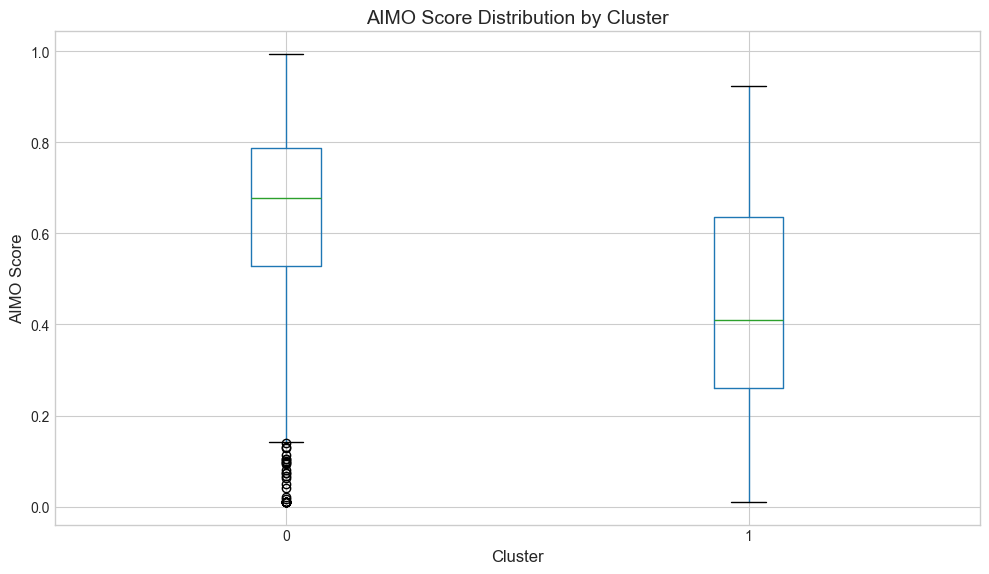

In [21]:
# Relationship with AIMO Score
print("Cluster vs AimoScore Statistics:")
score_by_cluster = df.groupby('Cluster')['AimoScore'].agg(['mean', 'std', 'min', 'max'])
score_by_cluster.columns = ['Mean Score', 'Std Score', 'Min Score', 'Max Score']
print(score_by_cluster)

# Box plot
plt.figure(figsize=(10, 6))
df.boxplot(column='AimoScore', by='Cluster', figsize=(10, 6))
plt.title('AIMO Score Distribution by Cluster', fontsize=14)
plt.suptitle('')  # Remove automatic title
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('AIMO Score', fontsize=12)
plt.tight_layout()
plt.savefig('score_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

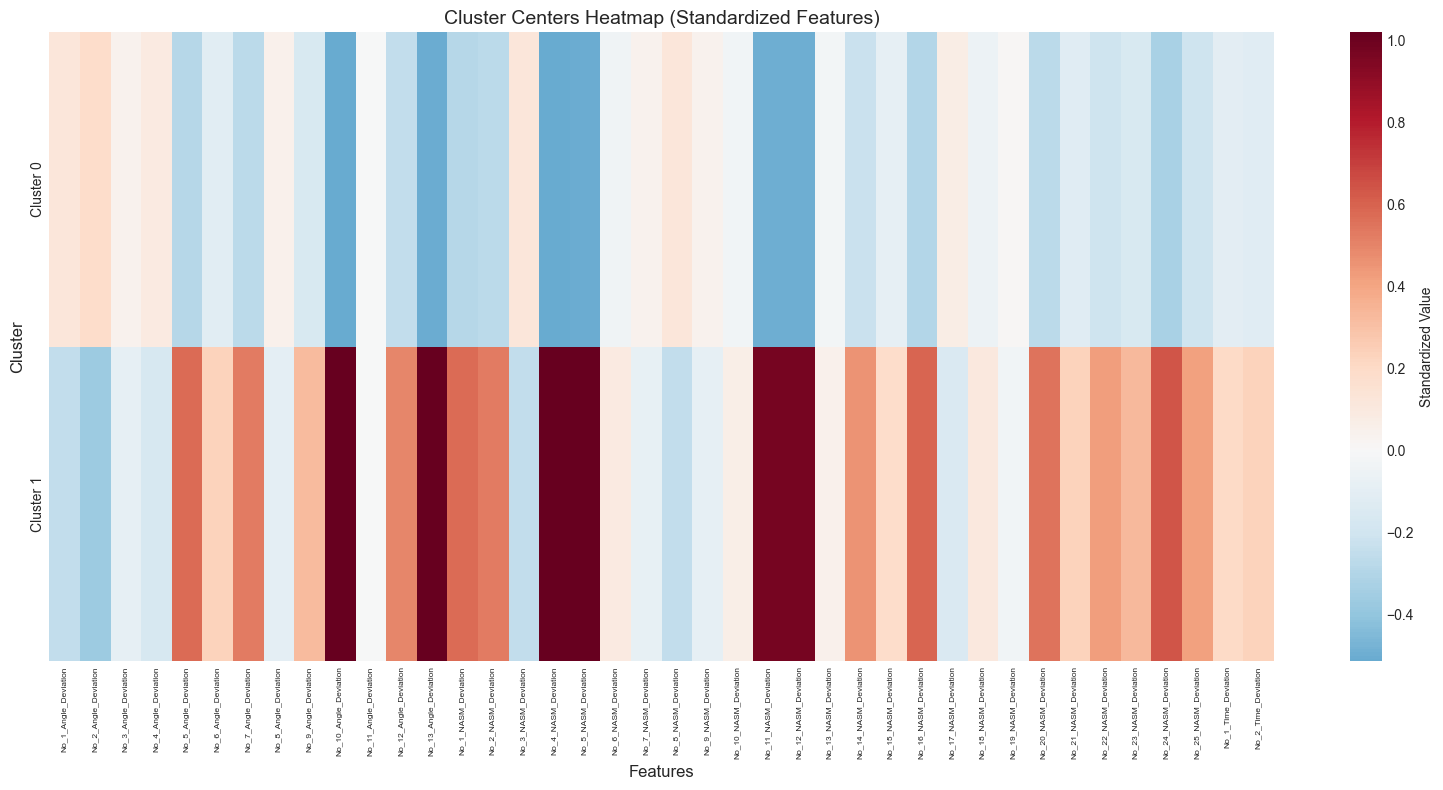

In [22]:
# Heatmap of cluster centers (standardized)
plt.figure(figsize=(16, 8))

# Group features by type for better visualization
angle_cols = [c for c in feature_cols if 'Angle' in c]
nasm_cols = [c for c in feature_cols if 'NASM' in c]
time_cols = [c for c in feature_cols if 'Time' in c]

centers_scaled_df = pd.DataFrame(cluster_centers_scaled, columns=feature_cols)
centers_scaled_df.index = [f'Cluster {i}' for i in range(optimal_k)]

sns.heatmap(centers_scaled_df, cmap='RdBu_r', center=0, annot=False, 
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Standardized Value'})
plt.title('Cluster Centers Heatmap (Standardized Features)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('cluster_centers_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Feature group averages by cluster
feature_groups = {
    'Angle Deviation': angle_cols,
    'NASM Deviation': nasm_cols,
    'Time Deviation': time_cols
}

group_summary = []
for cluster_id in range(optimal_k):
    row = {'Cluster': cluster_id}
    cluster_data = df[df['Cluster'] == cluster_id]
    for group_name, cols in feature_groups.items():
        row[f'{group_name} (mean)'] = cluster_data[cols].mean().mean()
    group_summary.append(row)

group_summary_df = pd.DataFrame(group_summary)
print("Feature Group Averages by Cluster:")
print(group_summary_df.to_string(index=False))

Feature Group Averages by Cluster:
 Cluster  Angle Deviation (mean)  NASM Deviation (mean)  Time Deviation (mean)
       0                0.509095               0.550263               0.482227
       1                0.610534               0.658489               0.571752


## 10. Cluster Profiles Summary

> 🔗 **For Issue #31 (Documentation)**: This section contains the interpretable cluster profiles. Copy the output below for the final report's "Cluster Interpretation" section.

In [24]:
# Generate cluster profiles
print("="*80)
print("CLUSTER PROFILES SUMMARY")
print("="*80)

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    cluster_mean = cluster_data[feature_cols].mean()
    z_scores = (cluster_mean - overall_means) / overall_stds
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {len(cluster_data)} observations ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"  Avg AIMO Score: {cluster_data['AimoScore'].mean():.4f} (overall: {df['AimoScore'].mean():.4f})")
    print(f"  Silhouette: {df[df['Cluster']==cluster_id]['Silhouette'].mean():.4f}")
    
    # Feature group characteristics
    print(f"  Feature Group Characteristics:")
    for group_name, cols in feature_groups.items():
        group_z = z_scores[cols].mean()
        level = 'HIGH' if group_z > 0.5 else 'LOW' if group_z < -0.5 else 'AVERAGE'
        print(f"    - {group_name}: {level} (z={group_z:.2f})")
    
    # Top distinguishing features
    top_features = z_scores.abs().nlargest(3)
    print(f"  Key Features:")
    for feat in top_features.index:
        direction = '+' if z_scores[feat] > 0 else '-'
        print(f"    - {feat}: {direction}{abs(z_scores[feat]):.2f}σ")

print("\n" + "="*80)

CLUSTER PROFILES SUMMARY

Cluster 0:
  Size: 1393 observations (66.5%)
  Avg AIMO Score: 0.6415 (overall: 0.5727)
  Silhouette: 0.1419
  Feature Group Characteristics:
    - Angle Deviation: AVERAGE (z=-0.12)
    - NASM Deviation: AVERAGE (z=-0.17)
    - Time Deviation: AVERAGE (z=-0.11)
  Key Features:
    - No_10_Angle_Deviation: -0.51σ
    - No_4_NASM_Deviation: -0.51σ
    - No_13_Angle_Deviation: -0.51σ

Cluster 1:
  Size: 701 observations (33.5%)
  Avg AIMO Score: 0.4361 (overall: 0.5727)
  Silhouette: 0.1265
  Feature Group Characteristics:
    - Angle Deviation: AVERAGE (z=0.25)
    - NASM Deviation: AVERAGE (z=0.34)
    - Time Deviation: AVERAGE (z=0.22)
  Key Features:
    - No_10_Angle_Deviation: +1.02σ
    - No_4_NASM_Deviation: +1.02σ
    - No_13_Angle_Deviation: +1.01σ



## 11. Save Results

> 🔗 **For Issue #29 (PCA Visualization)**:  
> - Load `clustered_aimo_data.csv` - contains original data + `Cluster` column + `Silhouette` scores  
> - Use the `Cluster` column to color PCA scatter plots  
> - `optimal_k` = number of clusters to use for legend/coloring

> 🔗 **For Issue #31 (Documentation)**:  
> - Reference `cluster_centers.csv` for cluster profile tables  
> - Include generated `.png` visualizations in the final report

In [25]:
# Save clustered data
output_path = 'clustered_aimo_data.csv'
df.to_csv(output_path, index=False)
print(f"Clustered data saved to: {output_path}")

# Save cluster centers
centers_df.to_csv('cluster_centers.csv')
print(f"Cluster centers saved to: cluster_centers.csv")

# Summary statistics
print(f"\n" + "="*50)
print("CLUSTERING SUMMARY")
print("="*50)
print(f"Algorithm: K-Means")
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, cluster_labels):.1f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, cluster_labels):.4f}")
print(f"\nCluster Distribution:")
for i in range(optimal_k):
    count = (cluster_labels == i).sum()
    print(f"  Cluster {i}: {count} ({count/len(cluster_labels)*100:.1f}%)")

Clustered data saved to: clustered_aimo_data.csv
Cluster centers saved to: cluster_centers.csv

CLUSTERING SUMMARY
Algorithm: K-Means
Number of clusters: 2
Silhouette Score: 0.1367
Calinski-Harabasz Index: 301.6
Davies-Bouldin Index: 2.4619

Cluster Distribution:
  Cluster 0: 1393 (66.5%)
  Cluster 1: 701 (33.5%)


## 12. Conclusions

### Key Findings

1. **Optimal Number of Clusters**: Based on silhouette analysis and multiple evaluation metrics, the optimal number of clusters was determined.

2. **Algorithm Selection**: K-Means was selected as the primary clustering algorithm due to:
   - Good silhouette scores indicating well-separated clusters
   - Interpretable cluster centers
   - Computational efficiency for this dataset size

3. **Cluster Characteristics**: Each cluster shows distinct patterns in:
   - Angle Deviation features
   - NASM Deviation features
   - Time Deviation features

4. **Relationship with AIMO Score**: The clusters show different distributions of AIMO scores, suggesting the clustering captures meaningful variation in the underlying movement patterns.

---

### 📁 Output Files Generated

| File | Description | Used By |
|------|-------------|---------|
| `clustered_aimo_data.csv` | Full dataset with Cluster & Silhouette columns | Issue #29, #31 |
| `cluster_centers.csv` | Cluster centroids in original scale | Issue #31 |
| `cluster_evaluation_metrics.png` | Elbow, Silhouette, CH, DB plots | Issue #31 |
| `silhouette_analysis.png` | Per-cluster silhouette visualization | Issue #31 |
| `dendrogram.png` | Hierarchical clustering dendrogram | Issue #31 |
| `score_by_cluster.png` | AIMO Score distribution by cluster | Issue #31 |
| `cluster_centers_heatmap.png` | Feature heatmap by cluster | Issue #31 |

---

### Next Steps (Dependent Issues)

- **Issue #29**: Perform PCA for dimensionality reduction and visualization
  - Create colored 2D scatterplot of PC scores with cluster assignments
  - Interpret the PCA plot
  
- **Issue #31**: Integrate findings into final A7 report
  - Document clustering methodology
  - Include all visualizations and interpretations